In [9]:
import torch.optim as optim
from src.utils import *
from src.algorithms import *
from src.losses import *
import deepinv as dinv
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from deepinv.models import DRUNet
from deepinv.optim.data_fidelity import L2
#from deepinv.optim.prior import PnP, ZeroPrior
from deepinv.optim import PGD
from deepinv.utils import load_example
from deepinv.utils.plotting import plot
from deepinv.optim.phase_retrieval import (
    correct_global_phase,
)
from deepinv.models.complex import to_complex_denoiser
from deepinv.optim.prior import PnP
import time
import numpy as np


BASE_DIR = Path(".")
RESULTS_DIR = BASE_DIR / "results"
# Set global random seed to ensure reproducibility.
torch.manual_seed(0)

import torch
import time
import numpy as np
import deepinv.optim.prior as prior

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [10]:
# Image size
img_size = 32
# The pixel values of the image are in the range [0, 1].
x = load_example(
    "SheppLogan.png",
    img_size=img_size,
    grayscale=True,
    resize_mode="resize",
    device=device,
)
print(x.min(), x.max())

tensor(0., device='cuda:0') tensor(0.7412, device='cuda:0')


In [11]:
x_phase = torch.exp(1j * x * torch.pi - 0.5j * torch.pi)

# Every element of the signal should have unit norm.
assert torch.allclose(x_phase.real**2 + x_phase.imag**2, torch.tensor(1.0))

In [12]:
# Define physics information
oversampling_ratio = 5.0
img_size = x.shape[1:]
m = int(oversampling_ratio * torch.prod(torch.tensor(img_size)))
n_channels = 1  # 3 for color images, 1 for gray-scale images

# Create the physics
physics = dinv.physics.RandomPhaseRetrieval(
    m=m,
    img_size=img_size,
    device=device,
)

# Generate measurements
y = physics(x_phase)

In [13]:
num_iter = 1000
x_true = x_phase.clone().detach()

[0] intensity_loss=99.635948  beta=0.000000  alpha=2.500e-01  ||x_k-x*||^2=208.762894
[20] intensity_loss=0.029003  beta=0.922320  alpha=1.000e+00  ||x_k-x*||^2=0.495145
[40] intensity_loss=0.000077  beta=1.160939  alpha=5.000e-01  ||x_k-x*||^2=0.001411
[60] intensity_loss=0.000000  beta=0.435750  alpha=5.000e-01  ||x_k-x*||^2=0.000001
[80] intensity_loss=0.000000  beta=0.672987  alpha=5.000e-01  ||x_k-x*||^2=0.000000
[100] intensity_loss=0.000000  beta=0.396378  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[120] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[140] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[160] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[180] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[200] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[220] intensity_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k

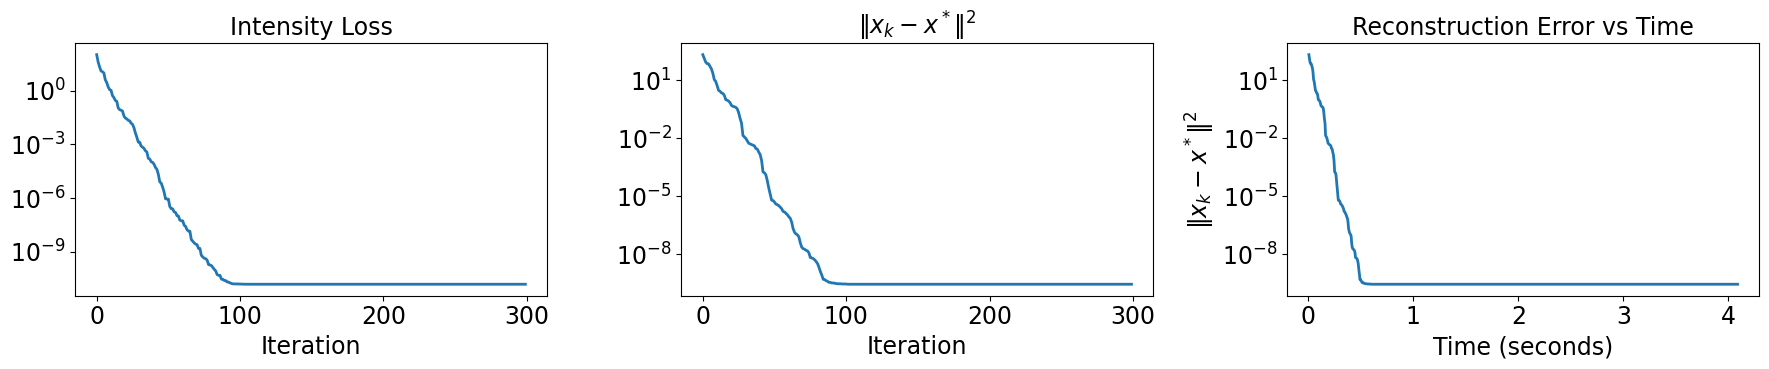

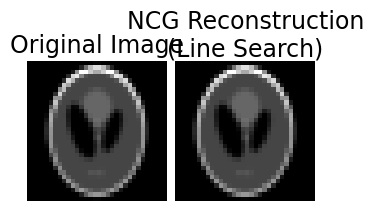

NCG+LS Final Loss:          0.000000
NCG+LS Final ||x_k-x*||^2:  0.000000


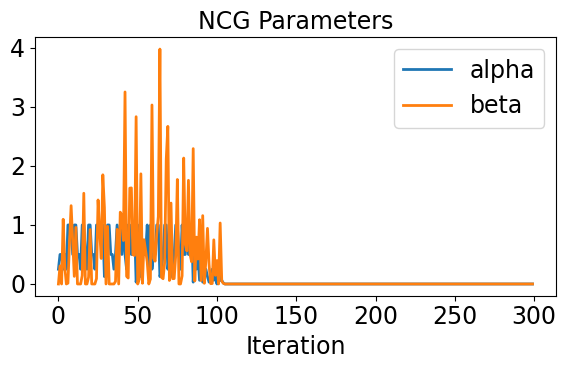

In [18]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()
x_true = x_phase.clone().detach()

result_ncg = nonlinear_conjugate_gradient(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=300,
    loss_type="intensity",
    beta_type="PR+",
    alpha0=1.0,
    rho=0.5,
    c=1e-4,
    min_alpha=1e-8,
    max_ls_steps=20,
    verbose=True
)

loss_hist = result_ncg["loss_hist"]
recon_error_hist = result_ncg["recon_error_hist"]
time_hist = result_ncg["time_hist"]
alpha_hist = result_ncg["alpha_hist"]
beta_hist = result_ncg["beta_hist"]
x_final = result_ncg["x_final"]

print_run_summary(
    loss_hist,
    result_ncg["total_time"],
    result_ncg["avg_time"],
    method_name="NCG+LS"
)

plot_metrics(
    loss_hist,
    recon_error_hist,
    time_hist,
    loss_name="Intensity Loss"
)

x_ncg_corrected = correct_global_phase(x_final, x_true)
x_ncg_recon = torch.angle(x_ncg_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_ncg_recon,
    title_recon="NCG Reconstruction (Line Search)"
)

final_recon_error = print_final_metrics(
    x_ncg_corrected,
    x_true,
    loss_hist,
    method_name="NCG+LS"
)

plt.figure(figsize=(6,4))
plt.plot(alpha_hist, label="alpha")
plt.plot(beta_hist, label="beta")
plt.xlabel("Iteration")
plt.title("NCG Parameters")
plt.legend()
plt.tight_layout()
plt.show()

GD semi-log convergence estimate
Fit range         : [4, 90]
slope             : -3.194211e-01
rho = exp(slope)  : 0.726570
C                 : 2.551163e+02
R^2               : 0.992519
ratio mean        : 0.763345
ratio median      : 0.815579
ratio std         : 0.171792
model             : e_k ≈ C * rho^k


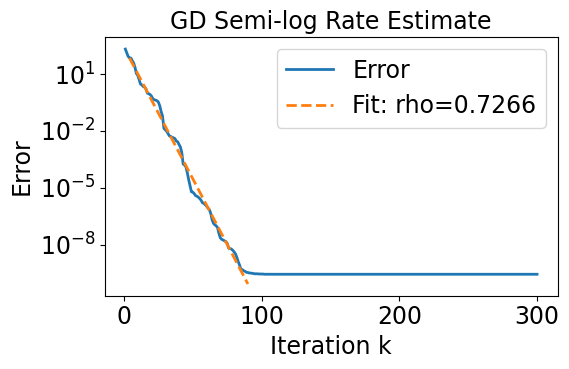

In [23]:
gd_rate = estimate_semilog_rate(
    error_hist=result_ncg["recon_error_hist"],
    start_ratio=0.01,
    end_ratio=0.3,
    method_name="GD",
    plot=True
)

[0] amplitude_loss=40.158909  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=130.256622
[20] amplitude_loss=0.049190  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.806522
[40] amplitude_loss=0.000870  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.017142
[60] amplitude_loss=0.000026  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.000546
[80] amplitude_loss=0.000001  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.000021
[100] amplitude_loss=0.000000  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.000001
[120] amplitude_loss=0.000000  beta=0.000000  alpha=1.000e+00  ||x_k-x*||^2=0.000000
[140] amplitude_loss=0.000000  beta=0.082052  alpha=1.000e+00  ||x_k-x*||^2=0.000000
[160] amplitude_loss=0.000000  beta=0.760783  alpha=5.000e-01  ||x_k-x*||^2=0.000000
[180] amplitude_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[200] amplitude_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k-x*||^2=0.000000
[220] amplitude_loss=0.000000  beta=0.000000  alpha=9.537e-07  ||x_k

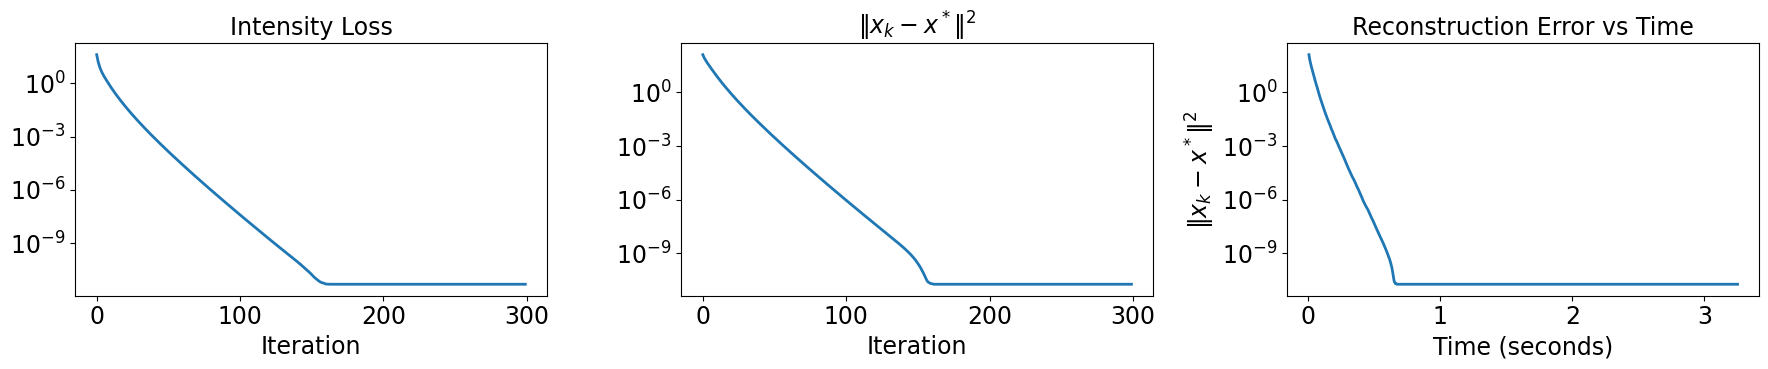

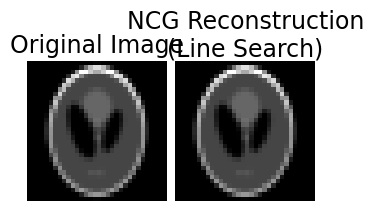

NCG+LS Final Loss:          0.000000
NCG+LS Final ||x_k-x*||^2:  0.000000


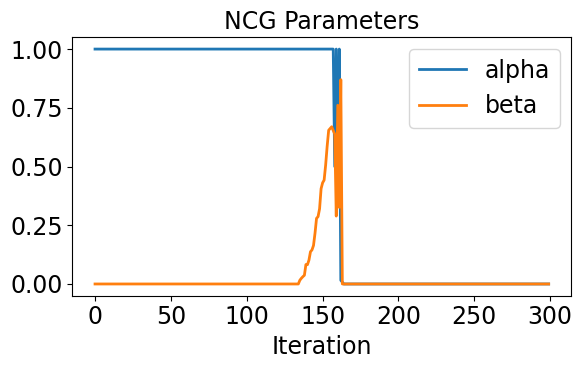

In [24]:
x_init = physics.A_dagger(y, n_iter=300).clone().detach()
x_true = x_phase.clone().detach()

result_ncg = nonlinear_conjugate_gradient(
    x_init=x_init,
    y=y,
    physics=physics,
    x_true=x_true,
    num_iter=300,
    loss_type="amplitude",
    beta_type="PR+",
    alpha0=1.0,
    rho=0.5,
    c=1e-4,
    min_alpha=1e-8,
    max_ls_steps=20,
    verbose=True
)

loss_hist = result_ncg["loss_hist"]
recon_error_hist = result_ncg["recon_error_hist"]
time_hist = result_ncg["time_hist"]
alpha_hist = result_ncg["alpha_hist"]
beta_hist = result_ncg["beta_hist"]
x_final = result_ncg["x_final"]

print_run_summary(
    loss_hist,
    result_ncg["total_time"],
    result_ncg["avg_time"],
    method_name="NCG+LS"
)

plot_metrics(
    loss_hist,
    recon_error_hist,
    time_hist,
    loss_name="Intensity Loss"
)

x_ncg_corrected = correct_global_phase(x_final, x_true)
x_ncg_recon = torch.angle(x_ncg_corrected) / torch.pi + 0.5
x_true_vis = torch.angle(x_true) / torch.pi + 0.5

plot_reconstruction(
    x_true_vis,
    x_ncg_recon,
    title_recon="NCG Reconstruction (Line Search)"
)

final_recon_error = print_final_metrics(
    x_ncg_corrected,
    x_true,
    loss_hist,
    method_name="NCG+LS"
)

plt.figure(figsize=(6,4))
plt.plot(alpha_hist, label="alpha")
plt.plot(beta_hist, label="beta")
plt.xlabel("Iteration")
plt.title("NCG Parameters")
plt.legend()
plt.tight_layout()
plt.show()

GD semi-log convergence estimate
Fit range         : [16, 120]
slope             : -1.671346e-01
rho = exp(slope)  : 0.846086
C                 : 1.829412e+01
R^2               : 0.998277
ratio mean        : 0.843815
ratio median      : 0.849039
ratio std         : 0.014960
model             : e_k ≈ C * rho^k


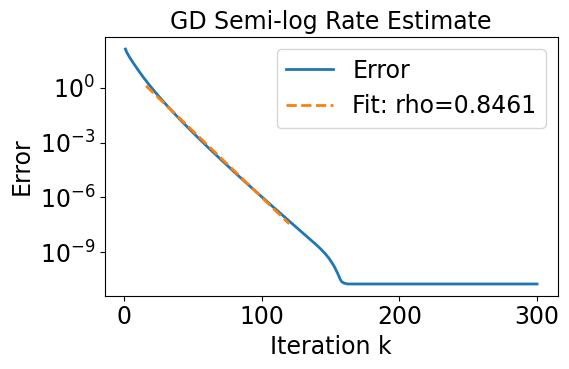

In [26]:
gd_rate = estimate_semilog_rate(
    error_hist=result_ncg["recon_error_hist"],
    start_ratio=0.05,
    end_ratio=0.4,
    method_name="GD",
    plot=True
)